# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = """
Artificial intelligence is transforming the way people interact with technology.
Deep learning models can learn useful patterns from large amounts of data.
Recurrent neural networks are powerful models for sequential data and text generation.
A SimpleRNN learns sequential patterns but may struggle with long term dependencies.
An LSTM uses memory cells and gates to remember important information for longer sequences.
A GRU uses update and reset gates and is often faster than an LSTM.
Text generation models learn from previous words and predict the next word in a sequence.
Natural language processing helps computers understand and generate human language.
Machine learning systems improve when they learn meaningful patterns from training data.
GestureConnect uses artificial intelligence to support communication through sign language.
Computer vision can recognize hand gestures from images and video frames.
A sign language translator can convert gestures into text and speech.
Deep learning and recurrent models can work together to build intelligent applications.
"""
print(corpus)



Artificial intelligence is transforming the way people interact with technology.
Deep learning models can learn useful patterns from large amounts of data.
Recurrent neural networks are powerful models for sequential data and text generation.
A SimpleRNN learns sequential patterns but may struggle with long term dependencies.
An LSTM uses memory cells and gates to remember important information for longer sequences.
A GRU uses update and reset gates and is often faster than an LSTM.
Text generation models learn from previous words and predict the next word in a sequence.
Natural language processing helps computers understand and generate human language.
Machine learning systems improve when they learn meaningful patterns from training data.
GestureConnect uses artificial intelligence to support communication through sign language.
Computer vision can recognize hand gestures from images and video frames.
A sign language translator can convert gestures into text and speech.
Deep learnin

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []

for line in corpus.strip().split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]

    # Progressive sliding-window n-gram sequences
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i + 1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)

# Pad all sequences to the same length
input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding='pre'
)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("Maximum sequence length:", max_len)
print("X shape:", X.shape)
print("y shape:", y.shape)


Vocabulary size: 104
Maximum sequence length: 15
X shape: (142, 14)
y shape: (142,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len - 1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla SimpleRNN training completed for 100 epochs")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla SimpleRNN training completed for 100 epochs


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len - 1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed for 100 epochs")


LSTM training completed for 100 epochs


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len - 1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed for 100 epochs")


GRU training completed for 100 epochs


## 📉 Compare Training Loss

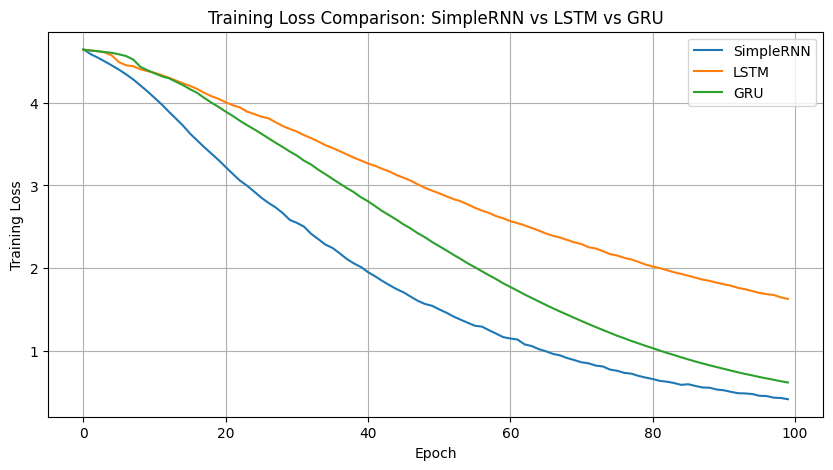

In [7]:
plt.figure(figsize=(10, 5))

plt.plot(rnn_history.history['loss'], label='SimpleRNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison: SimpleRNN vs LSTM vs GRU")
plt.legend()
plt.grid(True)
plt.show()


# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [10]:
def generate_text(model, seed_text, next_words=10):
    """
    Generate text by repeatedly selecting the word
    with the highest predicted probability.
    """

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len - 1,
            padding='pre'
        )

        # Predict probabilities for the next word
        predicted_probabilities = model.predict(
            token_list,
            verbose=0
        )

        # Select the index with the highest probability
        predicted = np.argmax(
            predicted_probabilities,
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break

        if output_word == "":
            break

        seed_text += " " + output_word

    return seed_text


## 🧪 Generate Text Samples

In [9]:
print("SimpleRNN :", generate_text(rnn_model, "deep learning", 10))
print("LSTM      :", generate_text(lstm_model, "deep learning", 10))
print("GRU       :", generate_text(gru_model, "deep learning", 10))


SimpleRNN : deep learning and recurrent models can work together to build intelligent applications
LSTM      : deep learning models models learn learn patterns from large amounts of data
GRU       : deep learning models can learn useful patterns from large amounts of data


# 📚 Student Learning Tasks — Completed

The following modifications have been applied:

1. Replaced the boilerplate corpus with a custom paragraph corpus.
2. Increased the embedding dimension from **32 to 64**.
3. Expanded training from **100 to 200 epochs** in the enhanced models below.
4. Increased hidden units from **64 to 128**.
5. Changed text generation from **5 words to 10 words**.


In [11]:
# Enhanced Student Models
# Student task configuration:
# Embedding dimension: 64
# Hidden units: 128
# Training epochs: 200

EMBEDDING_DIM = 64
HIDDEN_UNITS = 128
STUDENT_EPOCHS = 200

student_rnn_model = Sequential([
    Embedding(total_words, EMBEDDING_DIM, input_length=max_len - 1),
    SimpleRNN(HIDDEN_UNITS),
    Dense(total_words, activation='softmax')
])

student_lstm_model = Sequential([
    Embedding(total_words, EMBEDDING_DIM, input_length=max_len - 1),
    LSTM(HIDDEN_UNITS),
    Dense(total_words, activation='softmax')
])

student_gru_model = Sequential([
    Embedding(total_words, EMBEDDING_DIM, input_length=max_len - 1),
    GRU(HIDDEN_UNITS),
    Dense(total_words, activation='softmax')
])

# Same optimizer configuration for all three models
for model in [student_rnn_model, student_lstm_model, student_gru_model]:
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

student_rnn_history = student_rnn_model.fit(
    X, y, epochs=STUDENT_EPOCHS, verbose=0
)

student_lstm_history = student_lstm_model.fit(
    X, y, epochs=STUDENT_EPOCHS, verbose=0
)

student_gru_history = student_gru_model.fit(
    X, y, epochs=STUDENT_EPOCHS, verbose=0
)

print("Enhanced SimpleRNN training completed for 200 epochs")
print("Enhanced LSTM training completed for 200 epochs")
print("Enhanced GRU training completed for 200 epochs")


Enhanced SimpleRNN training completed for 200 epochs
Enhanced LSTM training completed for 200 epochs
Enhanced GRU training completed for 200 epochs


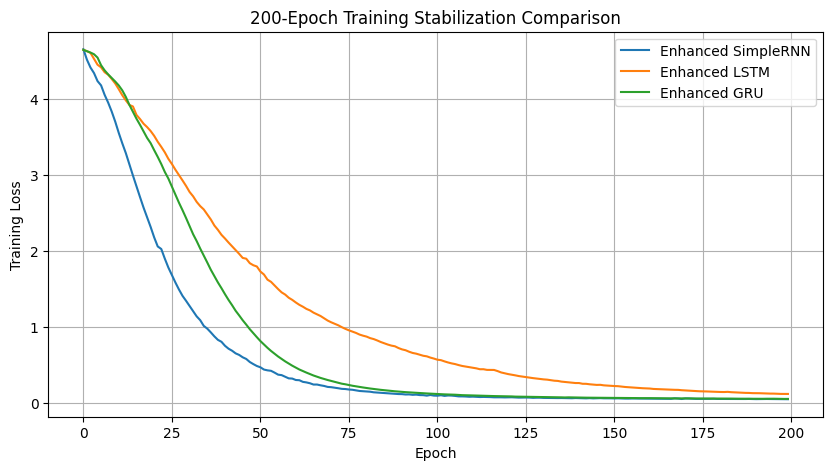

In [12]:
# Enhanced Training Trajectory Comparison

plt.figure(figsize=(10, 5))

plt.plot(student_rnn_history.history['loss'], label='Enhanced SimpleRNN')
plt.plot(student_lstm_history.history['loss'], label='Enhanced LSTM')
plt.plot(student_gru_history.history['loss'], label='Enhanced GRU')

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("200-Epoch Training Stabilization Comparison")
plt.legend()
plt.grid(True)
plt.show()


In [13]:
# Generate 10 words using the enhanced 200-epoch models

print("Enhanced SimpleRNN:",
      generate_text(student_rnn_model, "deep learning", 10))

print("Enhanced LSTM:",
      generate_text(student_lstm_model, "deep learning", 10))

print("Enhanced GRU:",
      generate_text(student_gru_model, "deep learning", 10))


Enhanced SimpleRNN: deep learning models can learn useful patterns from large amounts of data
Enhanced LSTM: deep learning and recurrent models can work together to build intelligent applications
Enhanced GRU: deep learning and recurrent models can work together to build intelligent applications


# ✅ Conclusion

This assignment compares three recurrent neural network architectures for text generation:

- **SimpleRNN:** A basic recurrent model that learns sequential patterns.
- **LSTM:** Uses memory cells and gates to preserve important long-term information.
- **GRU:** Uses reset and update gates and generally provides a simpler, efficient alternative to LSTM.

The project demonstrates:

1. Text cleaning and tokenization.
2. Integer word-index mapping.
3. Progressive n-gram sequence generation.
4. Sequence padding using `pad_sequences`.
5. Training of SimpleRNN, LSTM, and GRU models.
6. Comparison of training loss trajectories.
7. Next-word selection using `np.argmax`.
8. Custom corpus experimentation.
9. Increased embedding size and hidden-layer capacity.
10. Extended 200-epoch training and 10-word text generation.

The enhanced student version uses:
- **Embedding dimension:** 64
- **Hidden units:** 128
- **Training epochs:** 200
- **Generated words:** 10
